# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohamedahmed02/Flyrank-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
# ============================================================
# ML-06 — Setup
# ============================================================

!pip -q install -U duckdb huggingface_hub pyarrow

import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata

SEED = 42

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN was not found in Colab Secrets.")

os.environ["HF_TOKEN"] = HF_TOKEN

print("Environment ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.8/795.8 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.7 MB/s eta 0:00:00
Environment ready.


In [2]:
# ============================================================
# Build March/April content-level dataset
# ============================================================

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HTTP,
    EXTRA_HTTP_HEADERS MAP {{
        'Authorization': 'Bearer {HF_TOKEN}'
    }}
);
""")

MARCH_URL = (
    "https://huggingface.co/datasets/"
    "FlyRank/internship-warehouse/resolve/main/"
    "fact_content_daily_performance/month=2026-03/data_0.parquet"
)

APRIL_URL = (
    "https://huggingface.co/datasets/"
    "FlyRank/internship-warehouse/resolve/main/"
    "fact_content_daily_performance/month=2026-04/data_0.parquet"
)

dataset = con.execute(f"""
WITH march AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_clicks) AS gsc_clicks,
        SUM(gsc_impressions) AS gsc_impressions,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN CAST(SUM(gsc_sum_position) AS DOUBLE)
                 / SUM(gsc_impressions)
            ELSE NULL
        END AS gsc_avg_position,

        SUM(ga4_sessions) AS ga4_sessions,
        SUM(scroll_events) AS scroll_events

    FROM read_parquet('{MARCH_URL}')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
),

april AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_clicks) AS april_clicks

    FROM read_parquet('{APRIL_URL}')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
)

SELECT
    m.*,
    a.april_clicks,

    CASE
        WHEN a.april_clicks > m.gsc_clicks THEN 1
        ELSE 0
    END AS label

FROM march m

INNER JOIN april a
    ON m.client_hash_id = a.client_hash_id
    AND m.content_hash_id = a.content_hash_id
""").fetchdf()

print("Rows:", len(dataset))
print("Positive rate:", dataset["label"].mean())

display(dataset.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 158549
Positive rate: 0.17622943064919994


,client_hash_id,content_hash_id,gsc_clicks,gsc_impressions,gsc_avg_position,ga4_sessions,scroll_events,april_clicks,label
0,client_62f4a7e64f5e0096,content_39d7361b4945d504,0.0,77.0,4.311688,NaN,NaN,0.0,0
1,client_62f4a7e64f5e0096,content_c03ecafd4c999f15,22.0,10849.0,8.049866,NaN,NaN,23.0,1
2,client_62f4a7e64f5e0096,content_e689bc511192751a,0.0,61.0,5.885246,NaN,NaN,1.0,1
3,client_62f4a7e64f5e0096,content_7dbc094b799e05a4,1.0,705.0,5.863830,NaN,NaN,0.0,0
4,client_62f4a7e64f5e0096,content_40b10da45f4c1cb5,0.0,50.0,14.360000,NaN,NaN,0.0,0


## 1. Distributions

The main March decision-time signals are highly uneven in scale, so their distributions are inspected before testing relationships with the future April outcome.

Clicks, impressions, sessions, and scroll events are expected to be right-skewed because a relatively small number of content items can receive much larger volumes than the rest. Average position is inspected separately because lower values represent better search position.

,count,mean,std,min,25%,50%,75%,max,missing,median
gsc_clicks,158549.0,5.176721,28.165721,0.0,0.000000,0.00000,2.000000,5668.0,0,0.00000
gsc_impressions,158549.0,1768.034671,5706.756831,1.0,40.000000,246.00000,1264.000000,617124.0,0,246.00000
gsc_avg_position,158549.0,16.208524,17.725874,0.0,4.988779,8.47619,21.081522,309.0,0,8.47619
ga4_sessions,113853.0,10.863394,42.122961,0.0,0.000000,1.00000,5.000000,2603.0,44696,1.00000
scroll_events,113853.0,1.775913,8.105530,0.0,0.000000,0.00000,1.000000,667.0,44696,0.00000


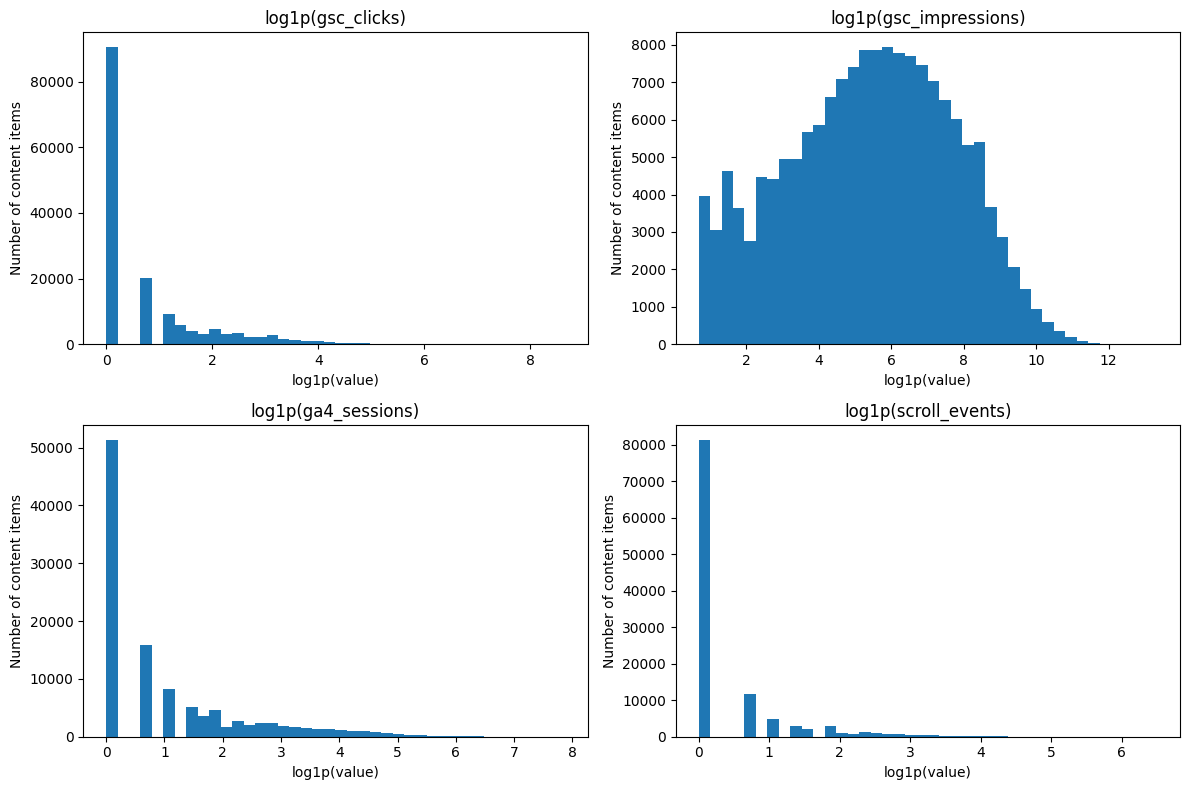

Distribution audit complete.


In [3]:
# ============================================================
# ML-06 — Section 1: Distributions
# ============================================================

signal_cols = [
    "gsc_clicks",
    "gsc_impressions",
    "gsc_avg_position",
    "ga4_sessions",
    "scroll_events",
]

summary = dataset[signal_cols].describe().T

summary["missing"] = dataset[signal_cols].isna().sum()
summary["median"] = dataset[signal_cols].median()

display(summary)

# Log-transformed distributions for heavy-tailed count signals
count_cols = [
    "gsc_clicks",
    "gsc_impressions",
    "ga4_sessions",
    "scroll_events",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), count_cols):
    values = dataset[col].dropna()
    ax.hist(np.log1p(values), bins=40)
    ax.set_title(f"log1p({col})")
    ax.set_xlabel("log1p(value)")
    ax.set_ylabel("Number of content items")

plt.tight_layout()
plt.show()

print("Distribution audit complete.")

## 2. Signal test #1 / #2 / #3 (verdict each)

Three March decision-time signals are tested against the April positive outcome using quantile buckets.

The tests use positive rate within each bucket rather than treating raw scale differences as evidence. A signal is considered CONFIRMED when the observed outcome changes consistently in the expected direction across buckets, OPPOSITE when the relationship consistently runs against the expectation, MIXED when the pattern is inconsistent, and FALSE when there is no useful separation.

In [4]:
# ============================================================
# ML-06 — Section 2: Signal tests
# ============================================================

def signal_test(df, feature, higher_expected=True, q=5):
    temp = df[[feature, "label"]].dropna().copy()

    temp["bucket"] = pd.qcut(
        temp[feature],
        q=q,
        duplicates="drop"
    )

    result = (
        temp.groupby("bucket", observed=True)
        .agg(
            n=("label", "size"),
            positive_rate=("label", "mean"),
            median_signal=(feature, "median")
        )
        .reset_index()
    )

    rates = result["positive_rate"].values

    diffs = np.diff(rates)

    if higher_expected:
        if np.all(diffs > 0):
            verdict = "CONFIRMED"
        elif np.all(diffs < 0):
            verdict = "OPPOSITE"
        elif np.any(diffs > 0) and np.any(diffs < 0):
            verdict = "MIXED"
        else:
            verdict = "FALSE"
    else:
        if np.all(diffs < 0):
            verdict = "CONFIRMED"
        elif np.all(diffs > 0):
            verdict = "OPPOSITE"
        elif np.any(diffs > 0) and np.any(diffs < 0):
            verdict = "MIXED"
        else:
            verdict = "FALSE"

    return result, verdict


# Test 1 — GSC clicks
clicks_result, clicks_verdict = signal_test(
    dataset,
    "gsc_clicks",
    higher_expected=True
)

print("Signal #1 — GSC clicks")
print("Verdict:", clicks_verdict)
display(clicks_result)


# Test 2 — GSC impressions
impressions_result, impressions_verdict = signal_test(
    dataset,
    "gsc_impressions",
    higher_expected=True
)

print("Signal #2 — GSC impressions")
print("Verdict:", impressions_verdict)
display(impressions_result)


# Test 3 — Average position
position_result, position_verdict = signal_test(
    dataset,
    "gsc_avg_position",
    higher_expected=False
)

print("Signal #3 — GSC average position")
print("Verdict:", position_verdict)
display(position_result)

Signal #1 — GSC clicks
Verdict: CONFIRMED


,bucket,n,positive_rate,median_signal
0,"(-0.001, 1.0]",110554,0.136114,0.0
1,"(1.0, 4.0]",19193,0.218152,3.0
2,"(4.0, 5668.0]",28802,0.302271,13.0


Signal #2 — GSC impressions
Verdict: CONFIRMED


,bucket,n,positive_rate,median_signal
0,"(0.999, 24.0]",31830,0.052152,7.0
1,"(24.0, 128.0]",31597,0.097129,61.0
2,"(128.0, 469.0]",31748,0.171507,247.0
3,"(469.0, 1825.0]",31666,0.255574,896.0
4,"(1825.0, 617124.0]",31708,0.305097,4429.0


Signal #3 — GSC average position
Verdict: MIXED


,bucket,n,positive_rate,median_signal
0,"(-0.001, 4.364]",31710,0.206307,3.029009
1,"(4.364, 6.79]",31710,0.208609,5.567664
2,"(6.79, 11.525]",31709,0.177048,8.476190
3,"(11.525, 26.0]",31751,0.176593,17.148718
4,"(26.0, 309.0]",31669,0.112507,41.191176


## 3. The flag-linked test

A practical content-review rule can use search position as an opportunity signal: content that already receives search visibility but ranks lower may be worth reviewing.

This test checks whether the March average-position signal separates April positive outcomes in the expected direction. Because lower average position represents better ranking, the expected relationship is inverse.

In [5]:
# ============================================================
# ML-06 — Section 3: Flag-linked test
# ============================================================

flag_test = dataset[
    [
        "gsc_avg_position",
        "gsc_impressions",
        "gsc_clicks",
        "label"
    ]
].dropna(subset=["gsc_avg_position"]).copy()

# Use position buckets to test the direction of the rule.
flag_test["position_bucket"] = pd.qcut(
    flag_test["gsc_avg_position"],
    q=5,
    duplicates="drop"
)

flag_result = (
    flag_test
    .groupby("position_bucket", observed=True)
    .agg(
        n=("label", "size"),
        positive_rate=("label", "mean"),
        median_position=("gsc_avg_position", "median"),
        median_impressions=("gsc_impressions", "median"),
        median_clicks=("gsc_clicks", "median")
    )
    .reset_index()
)

display(flag_result)

rates = flag_result["positive_rate"].values

if np.all(np.diff(rates) < 0):
    flag_verdict = "CONFIRMED"
elif np.all(np.diff(rates) > 0):
    flag_verdict = "OPPOSITE"
elif np.any(np.diff(rates) > 0) and np.any(np.diff(rates) < 0):
    flag_verdict = "MIXED"
else:
    flag_verdict = "FALSE"

print("Flag-linked signal: GSC average position")
print("Expected direction: lower position -> higher positive rate")
print("Verdict:", flag_verdict)

,position_bucket,n,positive_rate,median_position,median_impressions,median_clicks
0,"(-0.001, 4.364]",31710,0.206307,3.029009,645.0,1.0
1,"(4.364, 6.79]",31710,0.208609,5.567664,327.0,1.0
2,"(6.79, 11.525]",31709,0.177048,8.476190,234.0,0.0
3,"(11.525, 26.0]",31751,0.176593,17.148718,279.0,0.0
4,"(26.0, 309.0]",31669,0.112507,41.191176,113.0,0.0


Flag-linked signal: GSC average position
Expected direction: lower position -> higher positive rate
Verdict: MIXED


## 4. What this means in practice

The signal tests show which March search signals provide useful separation of the April outcome and which assumptions are weaker or mixed.

For content teams, these signals should be treated as prioritization evidence rather than automatic refresh triggers. A content item should enter human review based on the combined evidence, followed by inspection of search intent, relevance, quality, and freshness.

In [6]:
# ============================================================
# ML-06 — Section 4: Practical summary
# ============================================================

verdicts = pd.DataFrame({
    "signal": [
        "GSC clicks",
        "GSC impressions",
        "GSC average position",
        "Flag-linked average position"
    ],
    "verdict": [
        clicks_verdict,
        impressions_verdict,
        position_verdict,
        flag_verdict
    ]
})

display(verdicts)

print("\nSignal audit complete.")
print("Rows audited:", len(dataset))
print("Overall positive rate:", round(dataset["label"].mean(), 4))

,signal,verdict
0,GSC clicks,CONFIRMED
1,GSC impressions,CONFIRMED
2,GSC average position,MIXED
3,Flag-linked average position,MIXED



Signal audit complete.
Rows audited: 158549
Overall positive rate: 0.1762


The audit shows that GSC clicks and impressions are confirmed as useful directional signals for the future outcome. Average position shows a mixed relationship, so it should be treated as supporting context rather than a standalone decision rule.

For content teams, this suggests prioritizing multiple signals together instead of relying on a single threshold. The results are directional evidence from this dataset and do not establish causation.

In [7]:
print("Signal audit complete.")
print(f"Rows audited: {len(dataset)}")
print(f"Overall positive rate: {dataset['label'].mean():.4f}")

Signal audit complete.
Rows audited: 158549
Overall positive rate: 0.1762


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.